# Imports

Here we import the required libraries

In [1]:
'''%pip install torchsummary albumentations wandb --quiet
%pip install tqdm 
%pip install pandas 
%pip install torch
%pip install PIL
%pip install torchvision
%pip install matplotlib
%pip install scikit-learn
%pip install scikit-image
%pip install setuptools
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install optuna '''

'%pip install torchsummary albumentations wandb --quiet\n%pip install tqdm \n%pip install pandas \n%pip install torch\n%pip install PIL\n%pip install torchvision\n%pip install matplotlib\n%pip install scikit-learn\n%pip install scikit-image\n%pip install setuptools\n%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118\n%pip install optuna '

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
from __future__ import print_function, division

from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
tqdm_notebook.pandas()

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from numpy.typing import NDArray
from functools import reduce
from itertools import islice
import wandb
import math
from itertools import chain
import copy
from PIL import Image

import torch
from torch import nn
from torch import Tensor
from torch.optim import Optimizer
import torch.nn.functional as F
import torchvision 
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torchsummary import summary
# Import albumentations library in order to -use pre-built augmentations
import albumentations as A

from sklearn.model_selection import train_test_split
from multiprocessing import cpu_count

import os
import torch
import os.path as osp
from skimage import io, transform
import matplotlib.pyplot as plt
import typing as ty
import cv2
import optuna


from torchvision.models import resnet50, ResNet50_Weights
import torch.optim as optim


# Pero lo necesitamos para transforms.ToTensor() si no usaras ToTensorDict
from torchvision import transforms as T
from torchvision.ops import box_iou


import time
# Para el particionamiento


c:\Users\allc0363\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\allc0363\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
torch.manual_seed(32)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device}')
test = torch.ones((100, 100)).to(device)
del test
torch.cuda.empty_cache()

Using cuda


In [4]:
# Crear un generador para el DataLoader
generator = torch.Generator()
generator.manual_seed(42)

## Dataset

In [5]:
DATA_DIR = '../Datos/' #'/kaggle/input/fa-ii-2025-i-object-localization/'
WORK_DIR = '../Datos/' #'/kaggle/working'
DIR_Results = './Resultados/'
BATCH_SIZE = 32

img_dir = osp.join(DATA_DIR, "images/images")

df = pd.read_csv(osp.join(DATA_DIR, "train.csv"))

obj2id  = {'f16':0,'cougar':1,'chinook':2,'ah64':3,'f15':4,'seahawk':5}

id2obj  = {0:'f16',1:'cougar',2:'chinook',3:'ah64',4:'f15',5:'seahawk'}

df["class_id"] = df["class"].map(obj2id)

columns_f=['filename','xmin','ymin','xmax','ymax','class','class_id']

df= df[columns_f].copy()

## EDA

In [6]:
img_filename = osp.join(DATA_DIR, "images/images",'image_00077.jpeg')

img1 = cv2.imread(img_filename)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = io.imread(img_filename) # no necesita bgr2rgb

In [7]:
print(img1.shape)
print(img1.transpose((2,0,1)).shape)

(720, 1280, 3)
(3, 720, 1280)


In [8]:
list_image = list(df.filename)
data_shape = []
data_dim = []
data_w = []
data_h = []

for i in tqdm(list_image): ## tqdm(list_image)dura 40 segundos
    ruta_imagen = osp.join(img_dir, i)
    imagen = io.imread(ruta_imagen)
    shapes = imagen.shape
    dimen = imagen.ndim
    imagen = Image.open(ruta_imagen)
    w, h = imagen.size
    data_w.append(w)
    data_h.append(h)
    data_shape.append(shapes)
    data_dim.append(dimen)

data_w_h = pd.DataFrame([list_image,data_shape,data_dim,data_w,data_h]).T.rename(columns={0:'filename',1:'shapes',2:'ndim',3:'w',4:'h'}) 

100%|██████████| 189/189 [00:01<00:00, 129.76it/s]


In [9]:
data_w_h['w'].value_counts()

w
1280    189
Name: count, dtype: int64

In [10]:
data_w_h['ndim'].value_counts()


ndim
3    189
Name: count, dtype: int64

In [11]:
data_w_h['shapes'].value_counts()

shapes
(720, 1280, 3)    189
Name: count, dtype: int64

In [12]:
df['class_id'].value_counts()

class_id
0    41
1    37
2    35
3    34
4    23
5    19
Name: count, dtype: int64

In [13]:
df['class'].value_counts()

class
f16        41
cougar     37
chinook    35
ah64       34
f15        23
seahawk    19
Name: count, dtype: int64

In [14]:
df[df['xmin']>=df['xmax']].shape, df[df['ymin']>=df['ymax']].shape

((0, 7), (0, 7))

In [15]:
h_real=720
w_real=1280
h, w, c = 255, 400, 3 # The heigh, width and number of channels of each image

## Normalizamos los bboxes (En la siguiente monitoria hablaremos de la importancia)

In [16]:
print(df[["ymin", "ymax", "xmin", "xmax"]].describe())

             ymin        ymax        xmin         xmax
count  189.000000  189.000000  189.000000   189.000000
mean   186.396825  425.455026  401.238095   902.666667
std    112.079883  103.348946  232.361996   213.588688
min      1.000000  154.000000    1.000000   298.000000
25%    109.000000  359.000000  210.000000   730.000000
50%    188.000000  417.000000  418.000000   901.000000
75%    267.000000  494.000000  572.000000  1071.000000
max    440.000000  702.000000  944.000000  1280.000000


In [17]:
# Normalizar las columnas ymin, ymax, xmin, xmax
df[["ymin", "ymax"]] = df[["ymin", "ymax"]].div(h_real, axis=0)
df[["xmin", "xmax"]] = df[["xmin", "xmax"]].div(w_real, axis=0)


In [18]:
print(df[["ymin", "ymax", "xmin", "xmax"]].describe())

             ymin        ymax        xmin        xmax
count  189.000000  189.000000  189.000000  189.000000
mean     0.258884    0.590910    0.313467    0.705208
std      0.155667    0.143540    0.181533    0.166866
min      0.001389    0.213889    0.000781    0.232813
25%      0.151389    0.498611    0.164062    0.570312
50%      0.261111    0.579167    0.326562    0.703906
75%      0.370833    0.686111    0.446875    0.836719
max      0.611111    0.975000    0.737500    1.000000


## Particionamiento

In [19]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)



In [20]:
train_df['class'].value_counts(1) * 100

class
chinook    20.529801
f16        20.529801
cougar     18.543046
ah64       17.880795
f15        11.258278
seahawk    11.258278
Name: proportion, dtype: float64

In [21]:
val_df['class_id'].value_counts(1) * 100

class_id
0    26.315789
1    23.684211
3    18.421053
4    15.789474
2    10.526316
5     5.263158
Name: proportion, dtype: float64

In [22]:
# --- 0. Funciones y Clases Auxiliares ---
def reset_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

In [23]:
# --- Definiciones de Clases de Transformación (Asumidas) ---
class ToTensorDict:
    def __call__(self, sample):
        image, bbox, class_id = sample['image'], sample['bbox'], sample['class_id']
        image = image.transpose((2, 0, 1))
        sample['image'] = torch.from_numpy(image.copy()).float().div(255.0)
        sample['bbox'] = bbox 
        sample['class_id'] = class_id
        return sample

class NormalizeDict:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __call__(self, sample):
        sample['image'] = (sample['image'] - self.mean) / self.std
        return sample

## Clase para estructura de los datos

In [24]:
class militarDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, output_size=None, is_for_norm_calc=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.output_size = output_size 
        self.is_for_norm_calc = is_for_norm_calc

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        row = self.df.iloc[idx]
        img_filename = row['filename']
        img_path = os.path.join(self.img_dir, img_filename)
        default_img_size = (224,224) 

        try:
            pil_image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"Advertencia: Imagen no encontrada {img_path}. Usando placeholder gris.")
            size_for_dummy = self.output_size if self.output_size else default_img_size
            pil_image = Image.new('RGB', size_for_dummy, (128,128,128))
        except UnidentifiedImageError:
            print(f"Error: No se pudo identificar/abrir la imagen {img_path}. Usando placeholder.")
            size_for_dummy = self.output_size if self.output_size else default_img_size
            pil_image = Image.new('RGB', size_for_dummy, (128,0,0))


        if self.output_size:
            pil_image = pil_image.resize(self.output_size) 

        numpy_image = np.array(pil_image) 

        if self.is_for_norm_calc:
            scaled_image = torch.from_numpy(numpy_image.transpose(2, 0, 1)).float() / 255.0
            return {'image': scaled_image}

        # Estas coordenadas DEBEN estar normalizadas a [0,1] en el DataFrame que llega al Dataset
        bbox_coords = row[['xmin', 'ymin', 'xmax', 'ymax']].values.astype(np.float32)
        class_id_val = row['class_id']

        sample = {'image': numpy_image, 'bbox': bbox_coords, 'class_id': class_id_val}

        if self.transform:
            sample = self.transform(sample)
        
        current_bbox_data = sample['bbox']
        if not torch.is_tensor(current_bbox_data): 
            current_bbox_data = torch.tensor(current_bbox_data, dtype=torch.float32)
        
        bbox_tensor = current_bbox_data.unsqueeze(0) 
        class_id_tensor = torch.tensor(sample['class_id'], dtype=torch.long)

        return sample['image'], class_id_tensor, bbox_tensor


## Funciones para dibujar

In [25]:
def draw_predictions_example(images_np_list, classes_list, bboxes_list, color_rgb, text_org_tuple):
    drawn_images = []
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5 # Reducido para que quepa mejor
    thickness = 1    # Reducido para bboxes más finos

    for img_np_0_1, cls_id, bbox_0_1 in zip(images_np_list, classes_list, bboxes_list):
        img_to_draw_uint8 = (img_np_0_1.copy() * 255).astype(np.uint8)
        
        if not img_to_draw_uint8.flags['C_CONTIGUOUS']:
            img_to_draw_uint8 = np.ascontiguousarray(img_to_draw_uint8)

        h_img, w_img, _ = img_to_draw_uint8.shape

        # bbox_0_1 se espera que sean [xmin, ymin, xmax, ymax] normalizados a [0,1]
        xmin = int(bbox_0_1[0] * w_img)
        ymin = int(bbox_0_1[1] * h_img)
        xmax = int(bbox_0_1[2] * w_img)
        ymax = int(bbox_0_1[3] * h_img)

        # Validar que las coordenadas estén dentro de la imagen después de la conversión
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(w_img - 1, xmax)
        ymax = min(h_img - 1, ymax)

        # Solo dibujar si el bbox tiene un área válida
        if xmax > xmin and ymax > ymin:
            actual_color_rgb = color_rgb[0] 
            bgr_color = (actual_color_rgb[2], actual_color_rgb[1], actual_color_rgb[0])
            cv2.rectangle(img_to_draw_uint8, (xmin, ymin), (xmax, ymax), bgr_color, thickness)

            text_to_display = f"Cls:{cls_id}"
            (text_width, text_height), baseline = cv2.getTextSize(text_to_display, font, font_scale, thickness)
            
            text_x = xmin + text_org_tuple[0]
            text_y = ymin + text_org_tuple[1] 

            # Ajustar posición del texto para que esté dentro de la imagen y sea legible
            if text_y < text_height: # Si el offset lo saca por arriba
                 text_y = ymin + text_height + baseline + 2 # Ponerlo debajo del borde superior del bbox
            if text_y > ymax - baseline: # Si el offset lo saca por abajo
                 text_y = ymax - baseline - 2
            
            if text_x < 0: text_x = xmin + 2
            if text_x + text_width > w_img: text_x = xmax - text_width - 2


            # Fondo para el texto para mejor legibilidad
            cv2.rectangle(img_to_draw_uint8, (text_x, text_y - text_height - baseline), 
                          (text_x + text_width, text_y + baseline), bgr_color, -1) # -1 para relleno
            cv2.putText(img_to_draw_uint8, text_to_display, (text_x, text_y), font, 
                        font_scale, (255,255,255), thickness, cv2.LINE_AA) # Texto blanco sobre fondo de color
        
        drawn_images.append(img_to_draw_uint8)
    return drawn_images


## Graficamos una muestra de imagenes

Intentando leer dimensiones originales de las imágenes para normalizar bboxes...
Dimensiones originales leídas para 189 imágenes.
Columnas 'image_width'/'image_height' presentes. Normalizando BBoxes...
BBoxes normalizados y acotados a [0,1].


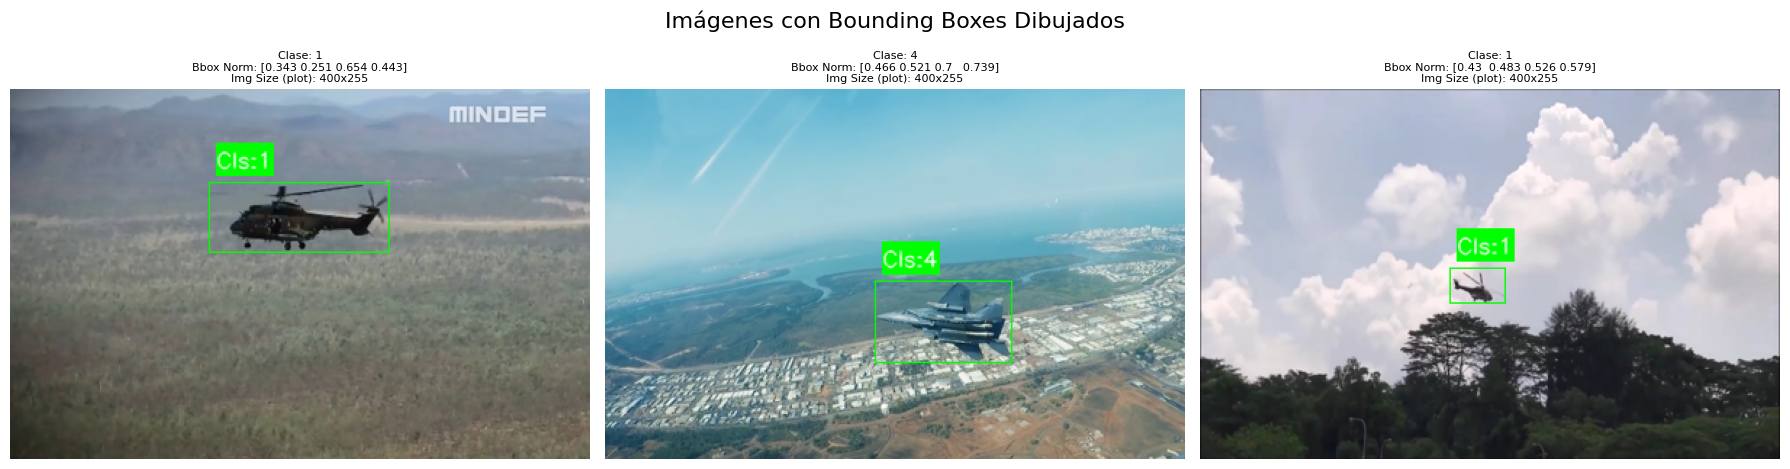

In [26]:
if __name__ == '__main__':
    DATA_DIR = '../Datos/' 
    temp_data_created = False
    if not os.path.exists(DATA_DIR):
        print(f"Directorio {DATA_DIR} no encontrado. Creando estructura dummy para prueba en './temp_data_for_plot'.")
        DATA_DIR = "./temp_data_for_plot"
        os.makedirs(os.path.join(DATA_DIR, "images/images"), exist_ok=True)
        temp_data_created = True

    img_dir_for_plot = os.path.join(DATA_DIR, "images/images") 
    df_full_path = os.path.join(DATA_DIR, "train.csv")

    if not os.path.exists(df_full_path) or temp_data_created:
        # ... (código de creación de CSV y imágenes dummy se mantiene igual) ...
        print(f"Archivo {df_full_path} no encontrado o se creó dir temporal. Creando train.csv dummy.")
        dummy_filenames = [f'dummy_img_{i}.png' for i in range(3)]
        dummy_data_for_csv = {
            'filename': dummy_filenames,
            'xmin': [0.1, 0.25, 0.5], 'ymin': [0.15, 0.3, 0.55],
            'xmax': [0.4, 0.65, 0.8], 'ymax': [0.45, 0.7, 0.85],
            'class': ['f16', 'cougar', 'chinook'],
        }
        df_full = pd.DataFrame(dummy_data_for_csv)
        df_full.to_csv(df_full_path, index=False)
        for fname in dummy_filenames:
            dummy_img_path = os.path.join(img_dir_for_plot, fname)
            if not os.path.exists(dummy_img_path):
                img_w, img_h = np.random.randint(300, 601), np.random.randint(200, 501)
                Image.new('RGB', (img_w, img_h), 
                          (np.random.randint(0,255), np.random.randint(0,255), np.random.randint(0,255))
                         ).save(dummy_img_path)
        print(f"train.csv dummy e imágenes creadas en {DATA_DIR}")
    else:
        df_full = pd.read_csv(df_full_path)

    obj2id = {'f16':0, 'cougar':1, 'chinook':2, 'ah64':3, 'f15':4, 'seahawk':5}
    df_full['class_id'] = df_full['class'].map(obj2id)
    
    for col in ['xmin', 'ymin', 'xmax', 'ymax']:
        if col in df_full.columns:
            df_full[col] = df_full[col].astype(float)

    # --- OBTENER DIMENSIONES ORIGINALES DE IMAGEN SI ES NECESARIO ---
    # Si 'image_width' y 'image_height' no están y los bboxes parecen absolutos,
    # intentamos leer las dimensiones de las imágenes originales.
    bboxes_are_likely_absolute = False
    if 'xmin' in df_full.columns: # Verificar si existen columnas de bbox
        # Heurística: si algún valor de bbox es > 1.0, probablemente son absolutos
        # (asumiendo que ningún objeto normalizado ocuparía más del 100% de la imagen)
        if ((df_full['xmin'] > 1.0) | (df_full['ymin'] > 1.0) |
            (df_full['xmax'] > 1.0) | (df_full['ymax'] > 1.0)).any():
            bboxes_are_likely_absolute = True

    if not ('image_width' in df_full.columns and 'image_height' in df_full.columns) and bboxes_are_likely_absolute:
        print("Intentando leer dimensiones originales de las imágenes para normalizar bboxes...")
        original_widths = []
        original_heights = []
        valid_indices = [] # Para mantener solo filas con imágenes válidas
        
        for idx, row in df_full.iterrows():
            img_path = os.path.join(img_dir_for_plot, row['filename'])
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    original_widths.append(w)
                    original_heights.append(h)
                    valid_indices.append(idx)
            except FileNotFoundError:
                print(f"Advertencia al leer dimensiones: Imagen {row['filename']} no encontrada. Se omitirá esta fila.")
            except UnidentifiedImageError:
                print(f"Advertencia al leer dimensiones: Imagen {row['filename']} no se pudo abrir/identificar. Se omitirá esta fila.")
            except Exception as e:
                print(f"Error inesperado al leer {row['filename']}: {e}. Se omitirá esta fila.")

        if valid_indices:
            df_full = df_full.loc[valid_indices].copy() # Usar .copy() para evitar SettingWithCopyWarning
            df_full['image_width'] = original_widths
            df_full['image_height'] = original_heights
            print(f"Dimensiones originales leídas para {len(valid_indices)} imágenes.")
        else:
            print("No se pudieron leer dimensiones para ninguna imagen. La normalización de BBox puede fallar si son absolutos.")


    # --- NORMALIZACIÓN DE BOUNDING BOXES (CRUCIAL) ---
    if 'image_width' in df_full.columns and 'image_height' in df_full.columns:
        # Asegurar que las columnas de dimensiones no tengan NaNs si se acaban de añadir o ya existían
        if df_full['image_width'].isnull().any() or df_full['image_height'].isnull().any():
            print("Error: Hay valores NaN en image_width o image_height. Eliminando filas afectadas.")
            df_full.dropna(subset=['image_width', 'image_height'], inplace=True)

        if not df_full.empty: # Continuar solo si el df no está vacío
            print("Columnas 'image_width'/'image_height' presentes. Normalizando BBoxes...")
            df_full['xmin'] = df_full['xmin'] / df_full['image_width']
            df_full['xmax'] = df_full['xmax'] / df_full['image_width']
            df_full['ymin'] = df_full['ymin'] / df_full['image_height']
            df_full['ymax'] = df_full['ymax'] / df_full['image_height']
            df_full[['xmin', 'ymin', 'xmax', 'ymax']] = df_full[['xmin', 'ymin', 'xmax', 'ymax']].clip(0.0, 1.0)
            print("BBoxes normalizados y acotados a [0,1].")
        else:
            print("DataFrame vacío después de eliminar NaNs en dimensiones. No se puede continuar.")
            exit()
    else:
        print("Advertencia: 'image_width'/'image_height' no disponibles.")
        print("Se ASUME que los BBoxes en el CSV ('xmin', 'ymin', 'xmax', 'ymax') YA ESTÁN NORMALIZADOS a [0,1].")
        if bboxes_are_likely_absolute:
             print("¡ALERTA! Esta suposición parece INCORRECTA según los valores de bbox. Los bboxes podrían no dibujarse correctamente.")


    columns_f = ['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class', 'class_id']
    # Añadir image_width, image_height si existen para referencia, aunque no se usen directamente en el Dataset si los bboxes ya están normalizados
    if 'image_width' in df_full.columns: columns_f.append('image_width')
    if 'image_height' in df_full.columns: columns_f.append('image_height')
    
    df_full = df_full.reindex(columns=columns_f).copy().dropna(subset=['class_id', 'xmin', 'ymin', 'xmax', 'ymax']) # Asegurar que bboxes no sean NaN
    if 'class_id' in df_full.columns: # Solo convertir si la columna existe y no es todo NaN
        df_full['class_id'] = df_full['class_id'].astype(int)
    
    num_samples_df = len(df_full)
    if num_samples_df == 0:
        print("Error: El DataFrame está vacío después del preprocesamiento. No se pueden generar muestras.")
        exit()
        
    train_df_for_plot = df_full.sample(n=min(3, num_samples_df), random_state=42)

    means_for_plot = np.array([0.485, 0.456, 0.406])
    stds_for_plot = np.array([0.229, 0.224, 0.225])
    
    w_vis, h_vis = 400, 255 

    vis_transforms = transforms.Compose([
        ToTensorDict(),
        NormalizeDict(mean=means_for_plot, std=stds_for_plot)
    ])

    plot_ds = militarDataset(train_df_for_plot,
                             img_dir=img_dir_for_plot,
                             output_size=(w_vis, h_vis), 
                             transform=vis_transforms)

    num_samples_to_plot = min(3, len(plot_ds))
    if num_samples_to_plot == 0:
        print("No hay muestras en el dataset para graficar.")
        if temp_data_created:
            import shutil
            print(f"Limpiando directorio temporal {DATA_DIR}")
            shutil.rmtree(DATA_DIR)
        exit()
        
    samples_from_ds = [plot_ds[i] for i in range(num_samples_to_plot)]

    images_to_plot = []
    bboxes_to_plot = []
    classes_to_plot = []

    mean_t = torch.tensor(means_for_plot, dtype=torch.float32).view(3, 1, 1)
    std_t = torch.tensor(stds_for_plot, dtype=torch.float32).view(3, 1, 1)

    for i in range(num_samples_to_plot):
        img_tensor, class_id_tensor, bbox_tensor_from_ds = samples_from_ds[i]

        img_denormalized = img_tensor.cpu() * std_t + mean_t
        img_np_hwc = img_denormalized.permute(1, 2, 0).numpy().clip(0, 1)
        images_to_plot.append(img_np_hwc)

        # bbox_tensor_from_ds es [1,4] y DEBERÍA estar normalizado [0,1] en este punto
        bbox_val_normalized = bbox_tensor_from_ds.squeeze().cpu().numpy() 
        bboxes_to_plot.append(bbox_val_normalized)
        classes_to_plot.append(class_id_tensor.item())

    drawn_imgs = draw_predictions_example(images_to_plot,
                                          classes_to_plot,
                                          bboxes_to_plot,
                                          color_rgb=[(0, 255, 0)], 
                                          text_org_tuple=(5, -10))

    cols_plot = min(num_samples_to_plot, 3)
    rows_plot = (num_samples_to_plot - 1) // cols_plot + 1 if cols_plot > 0 else 0
    if rows_plot > 0 :
        fig = plt.figure(figsize=(cols_plot * 6, rows_plot * 5)) # Aumentado tamaño por imagen

        for i, img_with_bbox in enumerate(drawn_imgs):
            ax = fig.add_subplot(rows_plot, cols_plot, i + 1)
            ax.imshow(img_with_bbox) 
            # Imprimir las coordenadas normalizadas que se pasaron a draw_predictions_example
            # y las dimensiones de la imagen sobre la que se dibujó
            img_h_plot, img_w_plot, _ = img_with_bbox.shape
            title_str = f"Clase: {classes_to_plot[i]}\n"
            title_str += f"Bbox Norm: {np.round(bboxes_to_plot[i], 3)}\n"
            title_str += f"Img Size (plot): {img_w_plot}x{img_h_plot}"
            ax.set_title(title_str, fontsize=8)
            ax.axis("off")
        
        plt.tight_layout()
        plt.suptitle("Imágenes con Bounding Boxes Dibujados", fontsize=16, y=1.03) # Ajustar y para suptitle
        plt.show()
    else:
        print("No hay imágenes para mostrar.")

    if temp_data_created:
        import shutil
        print(f"Limpiando directorio temporal {DATA_DIR}")
        shutil.rmtree(DATA_DIR)

## Normalización (Ahora de los píxeles, es diferente a la normalización anterior)

In [27]:
from torch.utils.data import DataLoader
import torch
import numpy as np

# Dataset para normalización
norm_dataset = militarDataset(df=train_df, img_dir=img_dir, is_for_norm_calc=True)
norm_loader = DataLoader(norm_dataset, batch_size=1, shuffle=False)

means = torch.zeros(3)
stds = torch.zeros(3)
n_images = 0

for sample in norm_loader:
    img = sample['image'].squeeze(0)  # img shape: (3, H, W)
    n_images += 1
    for c in range(3):
        means[c] += img[c].mean()
        stds[c] += img[c].std()

means /= n_images
stds /= n_images

print("Means:", means.tolist())
print("Stds:", stds.tolist())



Means: [0.5421594977378845, 0.5918400883674622, 0.6308855414390564]
Stds: [0.18581216037273407, 0.18579339981079102, 0.19440343976020813]


In [28]:
sample

{'image': tensor([[[[0.1294, 0.1294, 0.1294,  ..., 0.1255, 0.1255, 0.1255],
           [0.1294, 0.1294, 0.1294,  ..., 0.1255, 0.1255, 0.1255],
           [0.1294, 0.1294, 0.1294,  ..., 0.1255, 0.1255, 0.1255],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.1255, 0.1255, 0.1255,  ..., 0.1255, 0.1255, 0.1255],
           [0.1255, 0.1255, 0.1255,  ..., 0.1255, 0.1255, 0.1255],
           [0.1255, 0.1255, 0.1255,  ..., 0.1255, 0.1255, 0.1255],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.1059, 0.1059, 0.1059,  ..., 0.0863, 0.0863, 0.0863],
           [0.1059, 0.1059, 0.1059,  ..., 0.0863, 0.0863, 0.0863],
           [0.1

## Transformaciones

In [29]:
'''class ToTensorDict:
    def __call__(self, sample):
        image = sample['image']
        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        sample['image'] = image
        return sample

class NormalizeDict:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, sample):
        image = sample['image'] # Asume que es un Tensor CHW
        # Mi modificación:
        for c in range(image.shape[0]): # Itera sobre el número de canales detectado en la imagen
            image[c] = (image[c] - self.mean[c]) / self.std[c]
        sample['image'] = image
        return sample

train_transforms = transforms.Compose([ToTensorDict(), NormalizeDict(means, stds)])
eval_transforms = transforms.Compose([ToTensorDict(), NormalizeDict(means, stds)])
'''

"class ToTensorDict:\n    def __call__(self, sample):\n        image = sample['image']\n        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0\n        sample['image'] = image\n        return sample\n\nclass NormalizeDict:\n    def __init__(self, mean, std):\n        self.mean = mean\n        self.std = std\n\n    def __call__(self, sample):\n        image = sample['image'] # Asume que es un Tensor CHW\n        # Mi modificación:\n        for c in range(image.shape[0]): # Itera sobre el número de canales detectado en la imagen\n            image[c] = (image[c] - self.mean[c]) / self.std[c]\n        sample['image'] = image\n        return sample\n\ntrain_transforms = transforms.Compose([ToTensorDict(), NormalizeDict(means, stds)])\neval_transforms = transforms.Compose([ToTensorDict(), NormalizeDict(means, stds)])\n"

In [30]:
from torchvision import transforms

means_list = means.tolist()
stds_list = stds.tolist()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means_list, std=stds_list)
])


In [31]:
train_dataset = militarDataset(train_df, img_dir=img_dir, transform=transform)
val_dataset = militarDataset(val_df, img_dir=img_dir, transform=transform)


## Transfer Learning

In [33]:
class ResNet50MultiTaskModel(nn.Module):
    def __init__(self, num_classes=6, dropout=0.5, freeze_backbone=True):
        super(ResNet50MultiTaskModel, self).__init__()
        base_model = resnet50(weights=ResNet50_Weights.DEFAULT)
        if freeze_backbone:
            for param in base_model.parameters():
                param.requires_grad = False
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.classification_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2048, num_classes)
        self.bbox_dropout = nn.Dropout(dropout)
        self.bbox_regressor = nn.Linear(2048, 4) # Sin Sigmoid aquí, se aplicará antes de la pérdida si es necesario

    def forward(self, x):
        features = self.feature_extractor(x)
        pooled_features = self.pooling(features)
        flattened_features = self.flatten(pooled_features)
        class_output = self.classifier(self.classification_dropout(flattened_features))
        bbox_output = self.bbox_regressor(self.bbox_dropout(flattened_features))
        return class_output, bbox_output

In [35]:
base_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Arquitectura

## Metricas

In [36]:
def iou_metric(y_true_bbox: torch.Tensor, y_pred_bbox: torch.Tensor, apply_sigmoid_to_pred=False):
    # (Misma definición de iou_metric que en la respuesta anterior)
    # ... (copiarla aquí)
    if y_true_bbox.device != y_pred_bbox.device:
        y_true_bbox = y_true_bbox.to(y_pred_bbox.device)
    if apply_sigmoid_to_pred:
         y_pred_bbox = torch.sigmoid(y_pred_bbox)
    if y_true_bbox.ndim == 3 and y_true_bbox.shape[1] == 1:
        y_true_bbox = y_true_bbox.squeeze(1)
    if y_pred_bbox.ndim == 3 and y_pred_bbox.shape[1] == 1:
        y_pred_bbox = y_pred_bbox.squeeze(1)
    if y_true_bbox.shape[0] == 0 or y_pred_bbox.shape[0] == 0:
        return torch.tensor(0.0, device=y_pred_bbox.device)
    pairwise_iou_matrix = box_iou(y_true_bbox, y_pred_bbox)
    if pairwise_iou_matrix.shape[0] == pairwise_iou_matrix.shape[1]:
        return torch.diag(pairwise_iou_matrix).mean()
    elif pairwise_iou_matrix.numel() > 0:
        return pairwise_iou_matrix.mean()
    else:
        return torch.tensor(0.0, device=y_pred_bbox.device)

In [37]:
def accuracy_metric(y_pred_class: torch.Tensor, y_true_class: torch.Tensor):
    """
    Calcula la precisión de la clasificación.

    Args:
        y_pred_class (torch.Tensor): Logits o probabilidades predichas por el modelo.
                                     Shape: (batch_size, num_classes)
        y_true_class (torch.Tensor): Etiquetas de clase verdaderas.
                                     Shape: (batch_size,) o (batch_size, 1)
    Returns:
        torch.Tensor: Precisión.
    """
    # Obtener las clases predichas tomando el argmax
    pred_labels = torch.argmax(y_pred_class, dim=1)

    # Asegurar que y_true_class tenga la misma forma que pred_labels
    if y_true_class.ndim == 2 and y_true_class.shape[1] == 1:
        y_true_class = y_true_class.squeeze(1)

    # Comparar con las etiquetas verdaderas
    correct = torch.eq(pred_labels, y_true_class).float() # Convertir a float para la suma
    total = torch.ones_like(correct) # Un tensor de unos con la misma forma

    # Calcular la precisión
    acc = torch.sum(correct) / torch.sum(total) # o simplemente correct.mean()
    # result = torch.divide(torch.sum(correct), torch.sum(total)) # Como en tu imagen
    return acc

## Loss fn

In [38]:
def loss_fn_multitask(class_preds: torch.Tensor, bbox_preds: torch.Tensor,
                      true_classes: torch.Tensor, true_bboxes: torch.Tensor,
                      alpha: float = 0.5):
    """
    Calcula la pérdida combinada para clasificación y regresión de bounding box.

    Args:
        class_preds (torch.Tensor): Predicciones de clase del modelo (logits).
                                     Shape: (batch_size, num_classes)
        bbox_preds (torch.Tensor): Predicciones de bounding box del modelo.
                                   Shape: (batch_size, 4)
        true_classes (torch.Tensor): Etiquetas de clase verdaderas.
                                     Shape: (batch_size,) o (batch_size, 1) - deben ser long ints.
        true_bboxes (torch.Tensor): Coordenadas de bounding box verdaderas.
                                    Shape: (batch_size, 4)
        alpha (float): Peso para balancear la pérdida de regresión.
                       total_loss = (1-alpha)*cls_loss + alpha*reg_loss
    Returns:
        dict: Un diccionario con 'total_loss', 'cls_loss', 'reg_loss'.
    """
    # Asegurarse de que true_classes tenga el tipo de dato correcto para CrossEntropyLoss
    true_classes = true_classes.long()
    if true_classes.ndim == 2 and true_classes.shape[1] == 1:
        true_classes = true_classes.squeeze(1) # (batch_size, 1) -> (batch_size,)

    # Pérdida de Clasificación
    # class_preds son logits, true_classes son índices de clase
    cls_loss = F.cross_entropy(class_preds, true_classes)

    # Pérdida de Regresión para Bounding Box
    # bbox_preds y true_bboxes deben tener la misma forma [N, 4]
    # Usaremos MSELoss como en tu imagen, pero L1Loss (SmoothL1Loss) también es común
    reg_loss = F.mse_loss(bbox_preds, true_bboxes)
    # Alternativa: reg_loss = F.l1_loss(bbox_preds, true_bboxes)

    # Pérdida Total Combinada
    total_loss = (1 - alpha) * cls_loss + alpha * reg_loss

    return {
        'total_loss': total_loss,
        'reg_loss': reg_loss,
        'cls_loss': cls_loss
    }


## Callbacks

In [39]:
def printer_callback(logs: dict): # ty.Dict[str, ty.Any] si usas type hints
    """
    Imprime los logs del entrenamiento.
    """
    # print every 10 steps - asumiendo que 'iters' está en logs
    if 'iters' in logs and logs['iters'] % 10 != 0: # Cambié == a != para imprimir cada 10
        if logs['iters'] != 1: # Imprimir siempre la primera iteración
            return

    print(f"Iteración #: {logs.get('iters', 'N/A')}") # Usar .get para evitar KeyError
    for name, value in logs.items():
        if name == 'iters':
            continue

        if isinstance(value, (float, int)): # type(value) in [float, int] es menos idiomático
            value_str = f"{value:.4f}" if isinstance(value, float) else str(value)
        elif isinstance(value, torch.Tensor):
            # value_str = f"{value.item():.4f}" if value.numel() == 1 else str(value)
            value_str = f"{torch.round(value, decimals=4).item() if value.numel() == 1 else str(value.round(decimals=4))}"
        else:
            value_str = str(value)
        print(f"\t{name} = {value_str}")
    print("-" * 30) # Separador



## Training loop

In [40]:
def train_multitask_model(
    model, train_loader, val_loader, classification_criterion, bbox_criterion,
    optimizer, device, num_epochs=30, bbox_loss_weight=1.0, patience=5,
    model_save_path="best_multitask_model.pth", apply_sigmoid_to_bbox_pred=False
):
    # (Misma definición de train_multitask_model que en la respuesta anterior)
    # ... (copiarla aquí, asegurándose de que usa iou_metric correctamente)
    reset_seed(42)
    history = {
        'train_loss_cls': [], 'train_loss_bbox': [], 'train_loss_total': [], 'train_acc': [], 'train_iou': [],
        'val_loss_cls': [], 'val_loss_bbox': [], 'val_loss_total': [], 'val_acc': [], 'val_iou': []
    }
    best_val_loss_total = float('inf')
    epochs_no_improve = 0
    best_model_state = None
    print(f"Iniciando entrenamiento por {num_epochs} épocas en dispositivo: {device}.")
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        running_train_loss_cls, running_train_loss_bbox, running_train_loss_total = 0.0, 0.0, 0.0
        correct_train_preds, total_train_samples, sum_train_iou = 0, 0, 0.0
        for images, class_labels, bbox_labels_raw in train_loader:
            images = images.to(device)
            class_labels = class_labels.to(device).long()
            bbox_labels = bbox_labels_raw.to(device).float().squeeze(1)
            optimizer.zero_grad()
            class_logits, bbox_preds_raw = model(images)
            bbox_preds = torch.sigmoid(bbox_preds_raw) if apply_sigmoid_to_bbox_pred else bbox_preds_raw
            loss_cls = classification_criterion(class_logits, class_labels)
            loss_bbox = bbox_criterion(bbox_preds, bbox_labels)
            total_loss = loss_cls + bbox_loss_weight * loss_bbox
            total_loss.backward()
            optimizer.step()
            running_train_loss_cls += loss_cls.item() * images.size(0)
            running_train_loss_bbox += loss_bbox.item() * images.size(0)
            running_train_loss_total += total_loss.item() * images.size(0)
            _, predicted_classes = torch.max(class_logits, 1)
            correct_train_preds += (predicted_classes == class_labels).sum().item()
            total_train_samples += class_labels.size(0)
            sum_train_iou += iou_metric(bbox_labels.detach(), bbox_preds.detach(), apply_sigmoid_to_pred=False).item() * images.size(0)
        epoch_train_loss_cls = running_train_loss_cls / total_train_samples if total_train_samples > 0 else 0
        epoch_train_loss_bbox = running_train_loss_bbox / total_train_samples if total_train_samples > 0 else 0
        epoch_train_loss_total = running_train_loss_total / total_train_samples if total_train_samples > 0 else 0
        epoch_train_acc = correct_train_preds / total_train_samples if total_train_samples > 0 else 0
        epoch_train_iou = sum_train_iou / total_train_samples if total_train_samples > 0 else 0
        history['train_loss_cls'].append(epoch_train_loss_cls); history['train_loss_bbox'].append(epoch_train_loss_bbox)
        history['train_loss_total'].append(epoch_train_loss_total); history['train_acc'].append(epoch_train_acc)
        history['train_iou'].append(epoch_train_iou)
        model.eval()
        running_val_loss_cls, running_val_loss_bbox, running_val_loss_total = 0.0, 0.0, 0.0
        correct_val_preds, total_val_samples_val, sum_val_iou = 0, 0, 0.0 # Renombrado para evitar confusión
        current_epoch_val_loss_total = float('inf')
        if len(val_loader) > 0:
            with torch.no_grad():
                for images, class_labels, bbox_labels_raw in val_loader:
                    images = images.to(device)
                    class_labels = class_labels.to(device).long()
                    bbox_labels = bbox_labels_raw.to(device).float().squeeze(1)
                    class_logits, bbox_preds_raw = model(images)
                    bbox_preds = torch.sigmoid(bbox_preds_raw) if apply_sigmoid_to_bbox_pred else bbox_preds_raw
                    loss_cls = classification_criterion(class_logits, class_labels)
                    loss_bbox = bbox_criterion(bbox_preds, bbox_labels)
                    total_loss = loss_cls + bbox_loss_weight * loss_bbox
                    running_val_loss_cls += loss_cls.item() * images.size(0)
                    running_val_loss_bbox += loss_bbox.item() * images.size(0)
                    running_val_loss_total += total_loss.item() * images.size(0)
                    _, predicted_classes = torch.max(class_logits, 1)
                    correct_val_preds += (predicted_classes == class_labels).sum().item()
                    total_val_samples_val += class_labels.size(0)
                    sum_val_iou += iou_metric(bbox_labels.detach(), bbox_preds.detach(), apply_sigmoid_to_pred=False).item() * images.size(0)
            epoch_val_loss_cls = running_val_loss_cls / total_val_samples_val if total_val_samples_val > 0 else 0
            epoch_val_loss_bbox = running_val_loss_bbox / total_val_samples_val if total_val_samples_val > 0 else 0
            current_epoch_val_loss_total = running_val_loss_total / total_val_samples_val if total_val_samples_val > 0 else float('inf')
            epoch_val_acc = correct_val_preds / total_val_samples_val if total_val_samples_val > 0 else 0
            epoch_val_iou = sum_val_iou / total_val_samples_val if total_val_samples_val > 0 else 0
        else:
            epoch_val_loss_cls, epoch_val_loss_bbox, epoch_val_acc, epoch_val_iou = 0,0,0,0
        history['val_loss_cls'].append(epoch_val_loss_cls); history['val_loss_bbox'].append(epoch_val_loss_bbox)
        history['val_loss_total'].append(current_epoch_val_loss_total); history['val_acc'].append(epoch_val_acc)
        history['val_iou'].append(epoch_val_iou)
        epoch_duration = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{num_epochs} - Duración: {epoch_duration:.2f}s")
        print(f"  Train: LossCls={epoch_train_loss_cls:.4f}, LossBbox={epoch_train_loss_bbox:.4f}, Total={epoch_train_loss_total:.4f}, Acc={epoch_train_acc:.4f}, IoU={epoch_train_iou:.4f}")
        if total_val_samples_val > 0:
            print(f"  Valid: LossCls={epoch_val_loss_cls:.4f}, LossBbox={epoch_val_loss_bbox:.4f}, Total={current_epoch_val_loss_total:.4f}, Acc={epoch_val_acc:.4f}, IoU={epoch_val_iou:.4f}")
        else:
            print("  Valid: No hay datos de validación.")
        if total_val_samples_val > 0:
            if current_epoch_val_loss_total < best_val_loss_total:
                best_val_loss_total = current_epoch_val_loss_total
                best_model_state = copy.deepcopy(model.state_dict())
                torch.save(best_model_state, model_save_path)
                print(f"    Mejor modelo guardado en '{model_save_path}' con val_loss_total: {best_val_loss_total:.4f}")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                print(f"    Val_loss_total no mejoró. Paciencia: {epochs_no_improve}/{patience}")
            if epochs_no_improve >= patience:
                print(f"Early stopping activado después de {epoch+1} épocas.")
                break
        elif epoch == 0 and best_model_state is None:
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, model_save_path)
            print(f"    Modelo de la primera época guardado (sin validación) en '{model_save_path}'")
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Mejor estado del modelo cargado al final del entrenamiento.")
    else:
        print("No se guardó ningún estado del modelo.")
    print("Entrenamiento finalizado.")
    return model, history

## Run

In [41]:
if __name__ == '__main__':
    reset_seed(42)

    # --- Tus Variables de Configuración ---
    DATA_DIR = '../Datos/' # Ajusta esta ruta a tu estructura
    # WORK_DIR = '../Datos/' # O '/kaggle/working', no se usa directamente aquí
    # DIR_RESULTS = './Resultados/' # No se usa directamente aquí
    BATCH_SIZE = 32 # Como en tu imagen
    NUM_CLASSES = 6 # Basado en tu obj2id que llega hasta 5

    # --- Carga y Preprocesamiento del DataFrame (como en tus imágenes) ---
    print("Cargando y preprocesando el DataFrame...")
    img_dir = os.path.join(DATA_DIR, "images/images") # Tu img_dir
    try:
        df_original = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    except FileNotFoundError:
        print(f"Error: 'train.csv' no encontrado en {DATA_DIR}. Por favor, verifica la ruta.")
        exit()

    # Mapeo de clases (obj2id)
    obj2id = {'f16':0, 'cougar':1, 'chinook':2, 'ah64':3, 'f15':4, 'seahawk':5} # Como en tu imagen
    df_original['class_id'] = df_original['class'].map(obj2id)

    # Selección de columnas
    columns_f = ['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class', 'class_id']
    df = df_original[columns_f].copy()
    df = df.dropna(subset=['class_id']) # Eliminar filas donde class_id sea NaN después del mapeo
    df['class_id'] = df['class_id'].astype(int)


    # --- Normalización de Bounding Boxes (CRUCIAL) ---
    # Esta sección asume que tienes `w_real` y `h_real` como series de Pandas
    # con el ancho y alto de CADA imagen, o que todas las imágenes son del mismo tamaño
    # y `w_real` y `h_real` son escalares.
    # Si las dimensiones varían, este paso es mejor hacerlo DENTRO del Dataset __getitem__
    # después de cargar cada imagen.
    # Por ahora, replicaré la idea de que se hace en el DataFrame globalmente.
    # **NECESITAS PROPORCIONAR `w_real` y `h_real`**
    # Ejemplo (si todas las imágenes fueran, digamos, 1024x768):
    # W_REAL_SCALAR = 1024
    # H_REAL_SCALAR = 768
    # df[['xmin', 'xmax']] = df[['xmin', 'xmax']] / W_REAL_SCALAR
    # df[['ymin', 'ymax']] = df[['ymin', 'ymax']] / H_REAL_SCALAR

    # **Placeholder: Debes implementar esta parte según tus datos.**
    # Si no puedes obtener w_real y h_real aquí, deberás mover la normalización
    # del bbox al método __getitem__ del Dataset, usando las dimensiones de la imagen cargada.
    # Por ahora, para que el script corra, asumiré que ya están normalizadas o crearé unas dummy.
    # Intentaré leer dimensiones si están disponibles, sino usaré valores dummy [0,1]
    if 'image_width' in df.columns and 'image_height' in df.columns:
        print("Normalizando bounding boxes usando columnas 'image_width' y 'image_height' del DataFrame.")
        df['xmin'] = df['xmin'] / df['image_width']
        df['xmax'] = df['xmax'] / df['image_width']
        df['ymin'] = df['ymin'] / df['image_height']
        df['ymax'] = df['ymax'] / df['image_height']
    else:
        print("ADVERTENCIA: No se encontraron 'image_width'/'image_height' en el df para normalizar bboxes.")
        print("           Asegúrate que tus bboxes en el CSV ya estén normalizados a [0,1] o implementa la carga de dimensiones.")
        print("           Continuando con las coordenadas de bbox tal como están. Si no están en [0,1], SIGMOID EN EL MODELO/PÉRDIDA SERÁ INCORRECTO.")
        # Si ya están normalizados, esto es OK. Si no, es un problema.

    # Particionamiento del DataFrame
    print("Particionando el DataFrame...")
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class_id'])


    # --- Cálculo de Medias y Desviaciones para Normalización de Píxeles ---
    print("Calculando medias y desviaciones para la normalización de píxeles...")
    # Dataset temporal solo para este cálculo, solo convierte a tensor y escala
    temp_train_dataset = militarDataset(df=train_df, img_dir=img_dir, is_for_norm_calc=True)
    # Usar DataLoader es más eficiente si el dataset es grande
    temp_loader = DataLoader(temp_train_dataset, batch_size=BATCH_SIZE, num_workers=0, shuffle=False)

    means = torch.zeros(3)
    stds = torch.zeros(3)
    n_images = 0

    # Asegurarse que haya datos para calcular la media y std
    if len(temp_loader) > 0:
        for batch_sample in temp_loader:
            # militarDataset (con is_for_norm_calc=True) devuelve un dict {'image': tensor_img}
            # y DataLoader lo apila, así que batch_sample['image'] es [B, C, H, W]
            batch_img_tensors = batch_sample['image']
            for img_tensor in batch_img_tensors: # Iterar sobre imágenes en el batch
                for c in range(3):
                    means[c] += img_tensor[c, :, :].mean().item()
                    stds[c] += img_tensor[c, :, :].std().item()
                n_images += 1
        if n_images > 0:
            means /= n_images
            stds /= n_images
        else: # Fallback si n_images es 0 (dataset vacío)
            print("Dataset de entrenamiento vacío para cálculo de media/std. Usando valores por defecto de ImageNet.")
            means = torch.tensor([0.485, 0.456, 0.406])
            stds = torch.tensor([0.229, 0.224, 0.225])
    else: # Fallback si temp_loader está vacío
        print("Dataset de entrenamiento vacío para cálculo de media/std. Usando valores por defecto de ImageNet.")
        means = torch.tensor([0.485, 0.456, 0.406])
        stds = torch.tensor([0.229, 0.224, 0.225])

    print(f"Medias calculadas: {means}")
    print(f"Desviaciones calculadas: {stds}")


    # --- Definición de Transformaciones (usando tus clases) ---
    # Necesitas pasar los 'means' y 'stds' calculados (como tensores o listas/NumPy)
    # a NormalizeDict.
    # Si 'means' y 'stds' son tensores de PyTorch, conviértelos si es necesario
    # para NormalizeDict o ajusta NormalizeDict para que acepte tensores.
    # Mis clases NormalizeDict esperan listas/NumPy, así que convierto:
    train_transforms = T.Compose([
        ToTensorDict(),
        NormalizeDict(mean=means.tolist(), std=stds.tolist()) # .tolist() si son tensores
    ])
    eval_transforms = T.Compose([
        ToTensorDict(),
        NormalizeDict(mean=means.tolist(), std=stds.tolist())
    ])

    # --- Datasets y DataLoaders Finales ---
    print("Creando Datasets y DataLoaders finales...")
    train_dataset = militarDataset(df=train_df, img_dir=img_dir, transform=train_transforms)
    val_dataset = militarDataset(df=val_df, img_dir=img_dir, transform=eval_transforms)

    if len(train_dataset) > 0:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    else:
        train_loader = []
        print("Advertencia: El conjunto de entrenamiento final está vacío.")

    if len(val_dataset) > 0:
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    else:
        val_loader = []
        print("Advertencia: El conjunto de validación final está vacío.")


    # --- Configuración Adicional para Entrenamiento ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Usando dispositivo: {device}")

    model = ResNet50MultiTaskModel(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

    classification_criterion = nn.CrossEntropyLoss()
    bbox_criterion = nn.L1Loss() # L1 es generalmente bueno para bboxes

    params_to_train = [param for param in model.parameters() if param.requires_grad]
    if not params_to_train: # Si todos los parámetros están congelados
        print("Error: No hay parámetros para entrenar. Verifica 'freeze_backbone' y las capas del modelo.")
        # Descongelar el backbone o algunas capas si es necesario para el fine-tuning
        # O simplemente salir si esto es inesperado
        exit()

    optimizer = optim.Adam(params_to_train, lr=1e-4)

    # --- Iniciar Entrenamiento ---
    print("Iniciando el proceso de entrenamiento...")
    APPLY_SIGMOID_FLAG = True # Basado en que normalizaste tus bboxes a [0,1]
    print(f"APPLY_SIGMOID_TO_BBOX_PRED está configurado a: {APPLY_SIGMOID_FLAG}")


    if len(train_loader) > 0 :
        trained_model, history = train_multitask_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            classification_criterion=classification_criterion,
            bbox_criterion=bbox_criterion,
            optimizer=optimizer,
            device=device,
            num_epochs=15, # Ajusta el número de épocas
            bbox_loss_weight=1.0,
            patience=5,
            model_save_path="militar_multitask_model_v2.pth",
            apply_sigmoid_to_bbox_pred=APPLY_SIGMOID_FLAG
        )
        print("Entrenamiento completado.")
        # Aquí podrías añadir código para graficar el historial (history)
        # import matplotlib.pyplot as plt
        # plt.plot(history['train_loss_total'], label='Train Total Loss')
        # plt.plot(history['val_loss_total'], label='Val Total Loss')
        # plt.legend(); plt.show()
    else:
        print("No se ejecutó el entrenamiento porque el train_loader está vacío.")


Cargando y preprocesando el DataFrame...
ADVERTENCIA: No se encontraron 'image_width'/'image_height' en el df para normalizar bboxes.
           Asegúrate que tus bboxes en el CSV ya estén normalizados a [0,1] o implementa la carga de dimensiones.
           Continuando con las coordenadas de bbox tal como están. Si no están en [0,1], SIGMOID EN EL MODELO/PÉRDIDA SERÁ INCORRECTO.
Particionando el DataFrame...
Calculando medias y desviaciones para la normalización de píxeles...
Medias calculadas: tensor([0.5350, 0.5847, 0.6194])
Desviaciones calculadas: tensor([0.1886, 0.1899, 0.2027])
Creando Datasets y DataLoaders finales...
Usando dispositivo: cuda
Iniciando el proceso de entrenamiento...
APPLY_SIGMOID_TO_BBOX_PRED está configurado a: True
Iniciando entrenamiento por 15 épocas en dispositivo: cuda.
Epoch 1/15 - Duración: 22.94s
  Train: LossCls=1.7829, LossBbox=478.6475, Total=480.4305, Acc=0.1589, IoU=0.0000
  Valid: LossCls=1.7785, LossBbox=477.6114, Total=479.3899, Acc=0.1316, IoU

In [ ]:
from datetime import datetime
# Obtener la fecha y hora actual
ahora = datetime.now()
# Formatear como AAAAMMDD_HH_SS
fecha = ahora.strftime("%Y%m%d_%H_%S")
print(fecha)

In [ ]:

nom_modelo_entrenado = osp.join(DIR_Results,'pretrained_model_'+fecha+'.pth')
nom_submision = osp.join(DIR_Results,'submission_'+fecha+'.csv') 

# Save the model to disk
torch.save(model, nom_modelo_entrenado)

In [ ]:
# Perform inference on cpu in order to avoid memory problems 
device = 'cuda'
model = model.to(device)

test_root_dir = osp.join(DATA_DIR, "images/images")
test_df = pd.read_csv(osp.join(DATA_DIR, "test.csv"))

test_ds = militarDataset(test_df, root_dir=test_root_dir, labeled=False, transform=eval_transforms,output_size=(w,h))#
test_data = DataLoader(test_ds, batch_size=1, num_workers=0, shuffle=False)

class_preds = []
bbox_preds = []

for batch in test_data:
    batch_preds = model(batch['image'].float().to(device))
    
    class_pred = batch_preds['class_id'].argmax(-1).detach().cpu().numpy()
    bbox_pred = batch_preds['bbox'].detach().cpu().numpy()
    
    class_preds.append(class_pred.squeeze())
    bbox_preds.append(bbox_pred.squeeze())

In [ ]:
class_preds = np.array(class_preds)
bbox_preds = np.array(bbox_preds)

In [ ]:
submission = pd.DataFrame(
    index=test_df.filename,
    data={
        'class': class_preds,
        }
)
submission

In [ ]:
submission["xmin"] = bbox_preds[:, 0]*w_real
submission["ymin"] = bbox_preds[:, 1]*h_real
submission["xmax"] = bbox_preds[:, 2]*w_real
submission["ymax"] = bbox_preds[:, 3]*h_real

In [ ]:
submission['class']=submission['class'].replace(id2obj)
submission.to_csv(nom_submision)